<a href="https://colab.research.google.com/github/oleg61/DataScient/blob/Learn_AI/%D0%94%D0%97_3_%D0%92%D0%BE%D1%80%D0%BE%D0%BF%D0%B0%D0%B5%D0%B2_%D0%9E%D0%A1_arma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install 'numpy<2'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 67.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but 

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 9.0 MB/s eta 0:00:00


In [ ]:
!pip install pmdarima --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 16.7 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm
import statsmodels.api as sm
import statsmodels.tsa.api as smt

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import arma_order_select_ic
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_predict
plt.style.use('bmh')
%matplotlib inline

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Путь к датасету
DATA_PATH = '/content/drive/MyDrive/0. DataScients (Netology)/Временные ряды/1/'

# Загрузка датасета
series = pd.read_csv(DATA_PATH + 'weekly-closings-of-the-dowjones-.csv')['Close']
print("✅ Данные загружены")

✅ Данные загружены


In [ ]:
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (5, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))
        qq_ax = plt.subplot2grid(layout, (4, 0))

        y.plot(ax=ts_ax, color='blue', label='Original')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)
        sm.qqplot(y, line='s', ax=qq_ax)

        plt.tight_layout()
    return

Results of Dickey-Fuller Test:
Test Statistic                  -1.314625
p-value                          0.622455
#Lags Used                       0.000000
Number of Observations Used    161.000000
Critical Value (1%)             -3.471633
Critical Value (5%)             -2.879665
Critical Value (10%)            -2.576434
dtype: float64


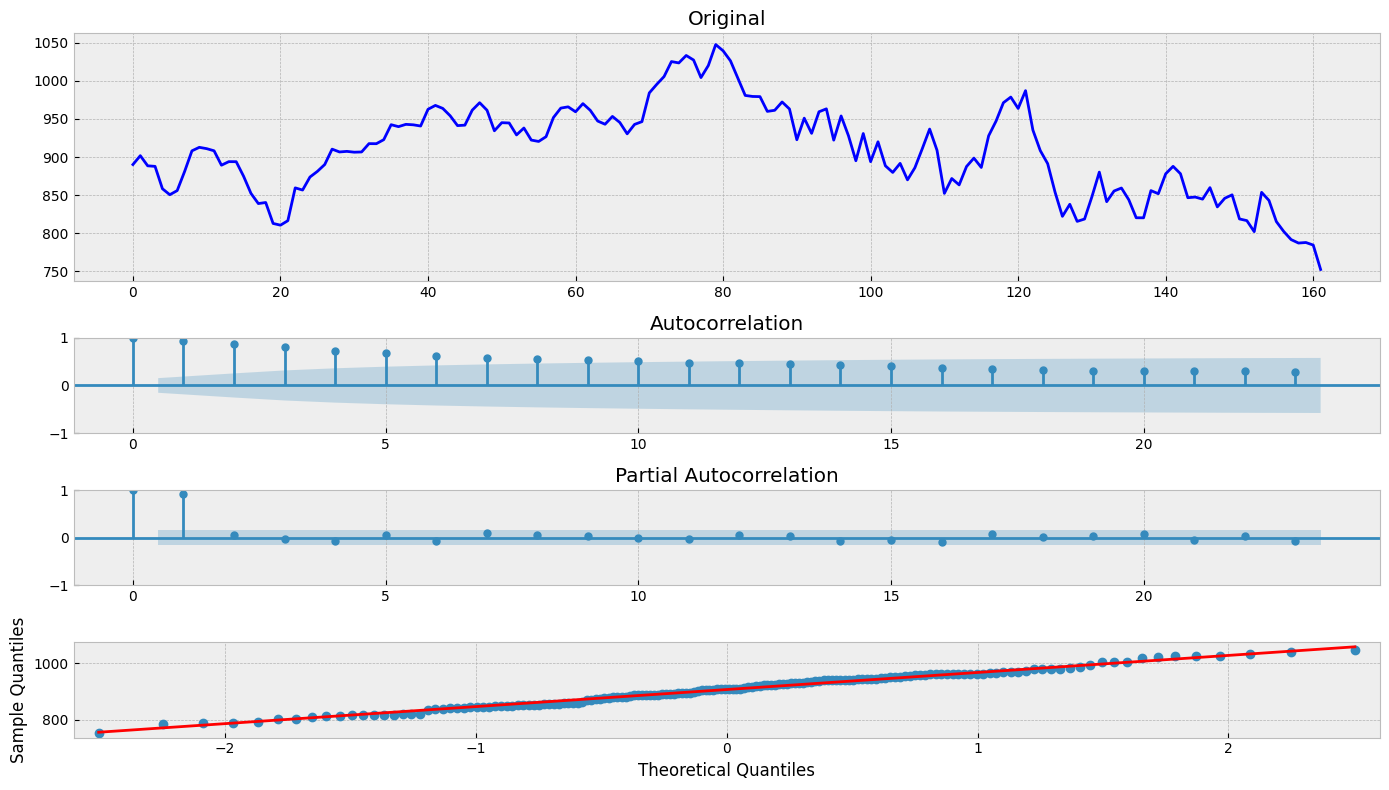

In [ ]:
# Исследование исходного ряда
tsplot(series)

Results of Dickey-Fuller Test:
Test Statistic                  -1.210369
p-value                          0.669119
#Lags Used                       0.000000
Number of Observations Used    161.000000
Critical Value (1%)             -3.471633
Critical Value (5%)             -2.879665
Critical Value (10%)            -2.576434
dtype: float64


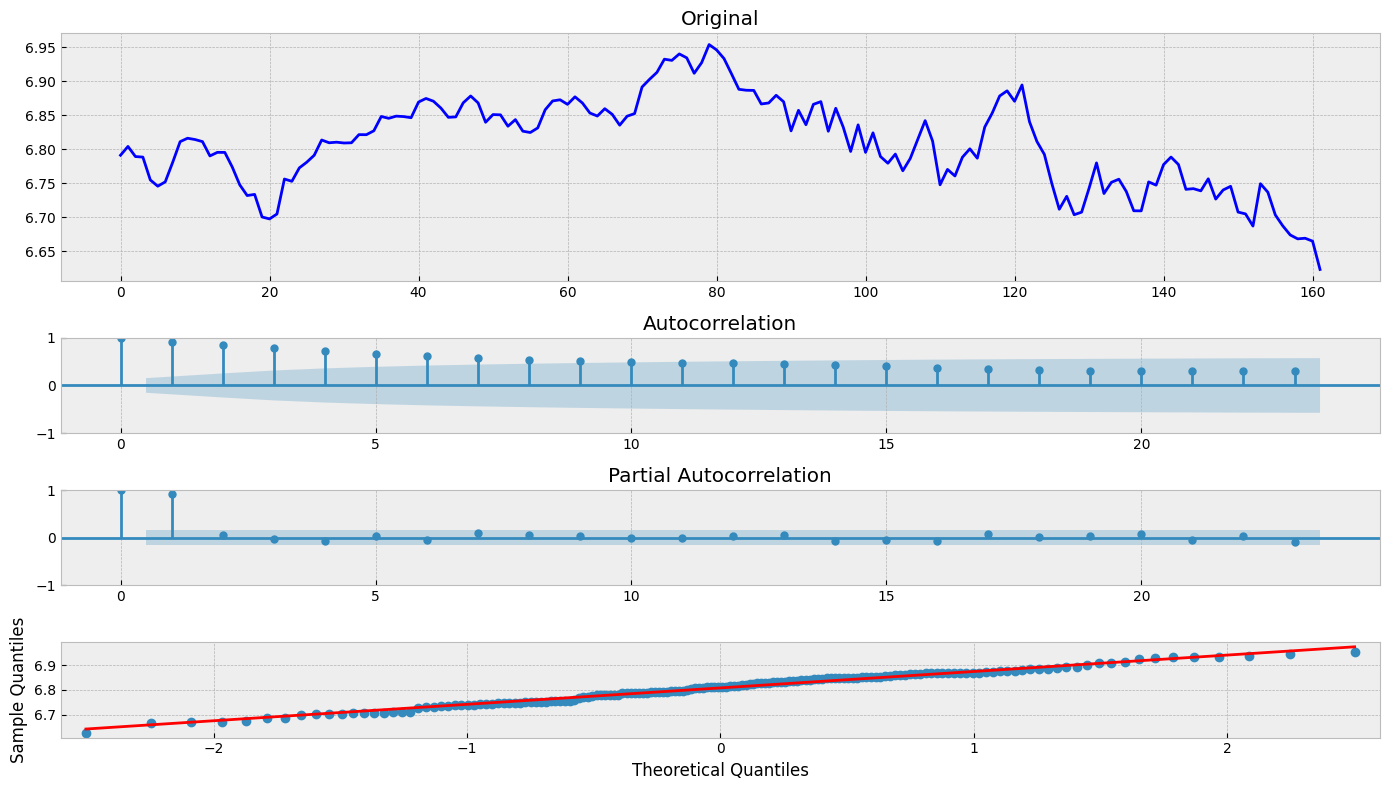

In [ ]:
# Преобразование Бокса-Кокса для стабилизации дисперсии
series_transformed = boxcox(series, 0)
tsplot(series_transformed)

In [ ]:
# Поиск оптимальных параметров для ARIMA
best_aic = np.inf
best_order = None
best_mdl = None

for i in range(5):
    for d in range(3):
        for j in range(5):
            try:
                tmp_mdl = ARIMA(series_transformed, order=(i, d, j)).fit()
                tmp_aic = tmp_mdl.aic
                if tmp_aic < best_aic:
                    best_aic = tmp_aic
                    best_order = (i, d, j)
                    best_mdl = tmp_mdl
            except:
                continue

print('ARIMA - aic: {:6.5f} | order: {}'.format(best_aic, best_order))

ARIMA - aic: -769.09926 | order: (1, 0, 0)


Results of Dickey-Fuller Test:
Test Statistic                -1.256967e+01
p-value                        2.017063e-23
#Lags Used                     0.000000e+00
Number of Observations Used    1.600000e+02
Critical Value (1%)           -3.471896e+00
Critical Value (5%)           -2.879780e+00
Critical Value (10%)          -2.576495e+00
dtype: float64


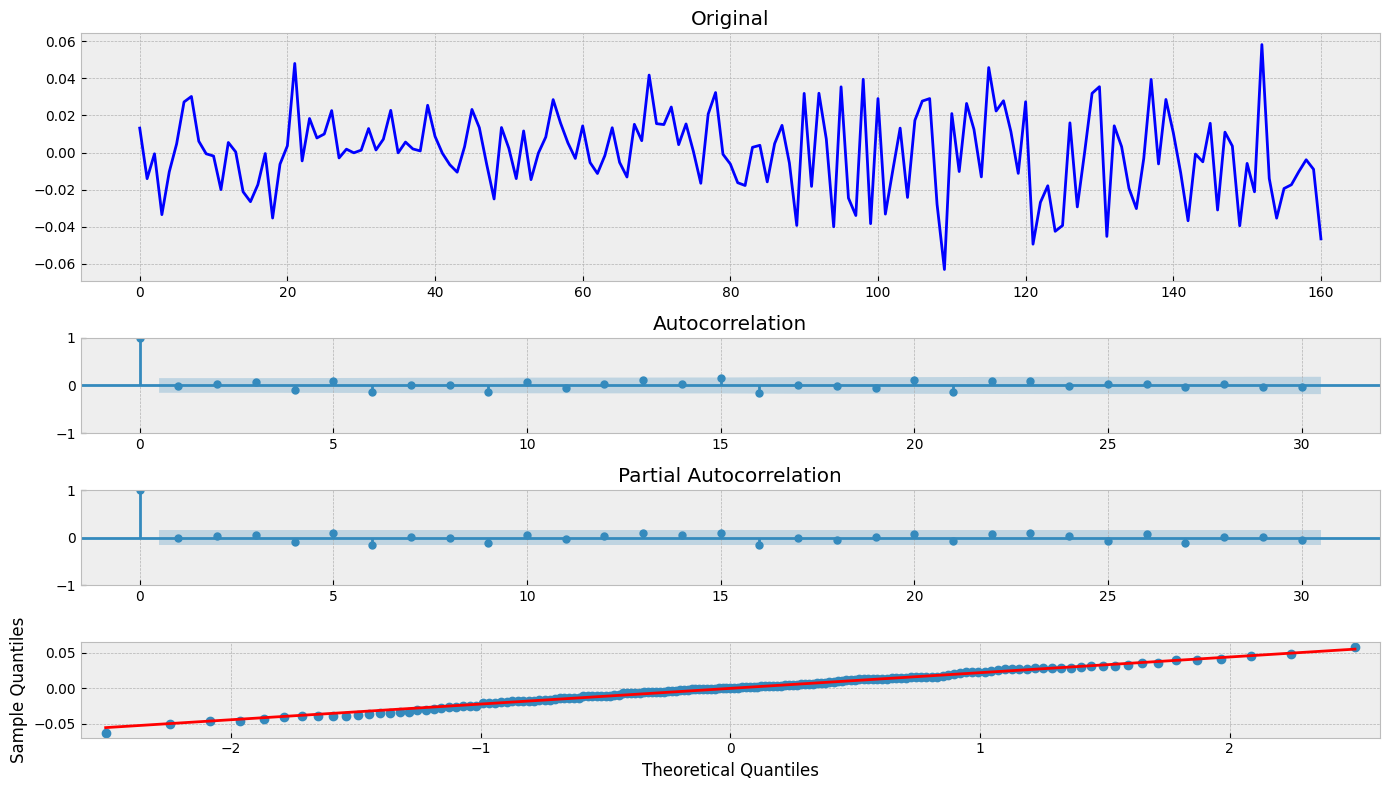

In [ ]:
# Построение графика остатков для ARIMA
tsplot(best_mdl.resid[1:], lags=30)

In [ ]:
# Применение GARCH к остаткам ARIMA
# Масштабируем остатки для улучшения сходимости
residuals_arima = best_mdl.resid[1:]  # исключаем первые значения, где нет остатков
residuals_scaled = residuals_arima * 100  # масштабирование

In [ ]:
# Подгоняем GARCH(1,1) к масштабированным остаткам
garch_model = arch_model(residuals_scaled, vol='GARCH', p=1, q=1)
garch_result = garch_model.fit(update_freq=0, disp='off')
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -347.854
Distribution:                  Normal   AIC:                           703.708
Method:            Maximum Likelihood   BIC:                           716.033
                                        No. Observations:                  161
Date:                Sun, Nov 09 2025   Df Residuals:                      160
Time:                        21:15:16   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.1652      0.164      1.005      0.315 [ -0.157,  0.48

Results of Dickey-Fuller Test:
Test Statistic                -1.256967e+01
p-value                        2.017063e-23
#Lags Used                     0.000000e+00
Number of Observations Used    1.600000e+02
Critical Value (1%)           -3.471896e+00
Critical Value (5%)           -2.879780e+00
Critical Value (10%)          -2.576495e+00
dtype: float64


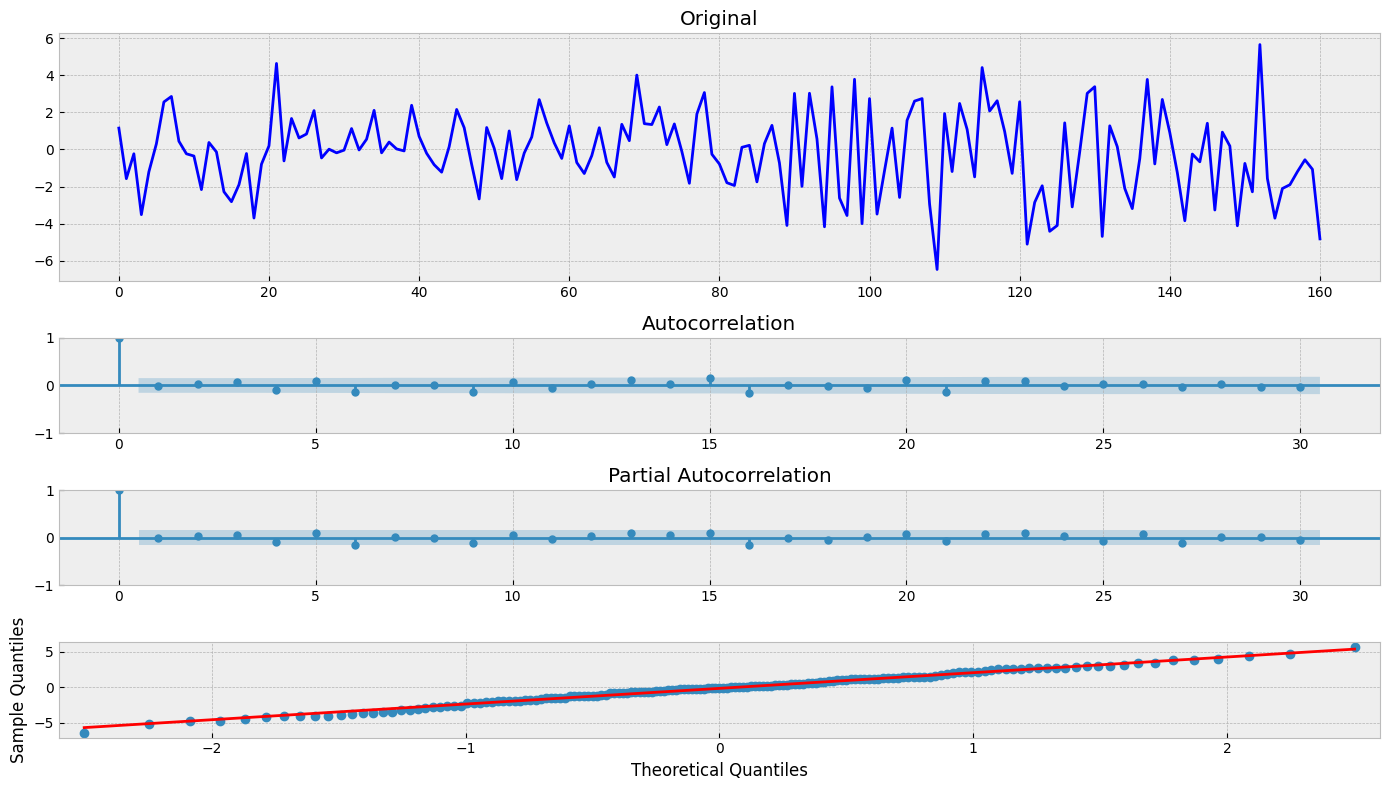

In [ ]:
# Построение графика остатков GARCH
tsplot(garch_result.resid, lags=30)

In [ ]:
# Подготовка признаков для классического ML
def create_features(series, lags):
    df = pd.DataFrame(series)
    df.columns = ['y']
    for lag in range(1, lags+1):
        df[f'lag_{lag}'] = df['y'].shift(lag)
    df.dropna(inplace=True)
    X = df.drop(columns=['y'])
    y = df['y']
    return X, y

X, y = create_features(series, lags=5)

In [ ]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Обучение модели Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Предсказания
rf_pred = rf_model.predict(X_test)

In [ ]:
# Оценка качества
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_pred)
print(f"Random Forest - MSE: {rf_mse:.4f}, RMSE: {rf_rmse:.4f}, MAE: {rf_mae:.4f}")

Random Forest - MSE: 1033.3326, RMSE: 32.1455, MAE: 26.9405


In [ ]:
# Обучение линейной регрессии
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [ ]:
# Оценка качества
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_pred)
print(f"Linear Regression - MSE: {lr_mse:.4f}, RMSE: {lr_rmse:.4f}, MAE: {lr_mae:.4f}")

Linear Regression - MSE: 590.7734, RMSE: 24.3058, MAE: 18.6916


Results of Dickey-Fuller Test:
Test Statistic                -1.072290e+01
p-value                        3.117967e-19
#Lags Used                     0.000000e+00
Number of Observations Used    1.240000e+02
Critical Value (1%)           -3.484220e+00
Critical Value (5%)           -2.885145e+00
Critical Value (10%)          -2.579359e+00
dtype: float64


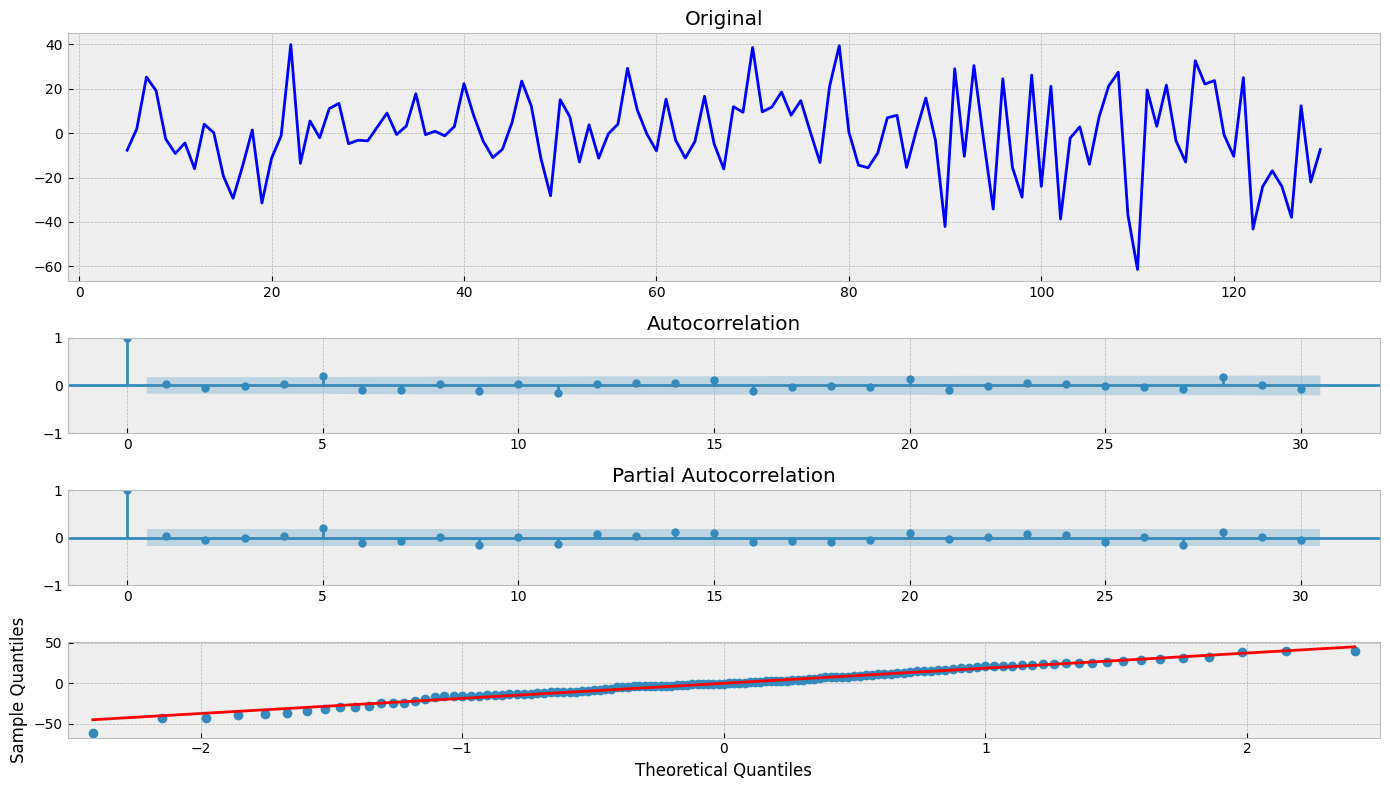

In [ ]:
# Построение графика остатков для ML модели (на обучающих данных)
lr_train_pred = lr_model.predict(X_train)
residuals = y_train - lr_train_pred
tsplot(residuals, lags=30)

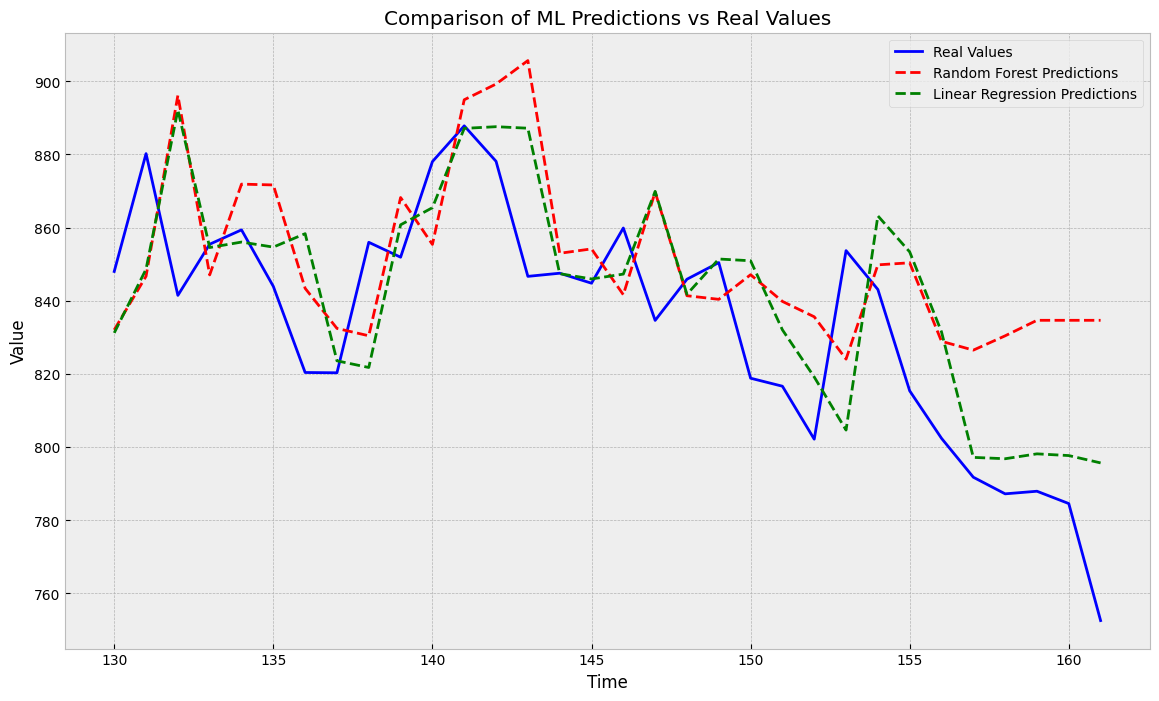

In [ ]:
# Визуализация предсказаний
plt.figure(figsize=(14, 8))
plt.plot(y_test.index, y_test.values, label='Real Values', color='blue')
plt.plot(y_test.index, rf_pred, label='Random Forest Predictions', color='red', linestyle='--')
plt.plot(y_test.index, lr_pred, label='Linear Regression Predictions', color='green', linestyle='--')
plt.title('Comparison of ML Predictions vs Real Values')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:
# ARIMA forecast
n_steps = len(y_test)
arima_forecast = best_mdl.forecast(steps=n_steps)

In [ ]:
# Возвращаем прогноз ARIMA к оригинальному масштабу (если использовалось преобразование)
# В данном случае Box-Cox не требует обратного преобразования для прогноза
arima_rmse = sqrt(mean_squared_error(y_test, arima_forecast))
arima_mae = mean_absolute_error(y_test, arima_forecast)
print(f"ARIMA - RMSE: {arima_rmse:.4f}, MAE: {arima_mae:.4f}")

ARIMA - RMSE: 828.5066, MAE: 827.9094


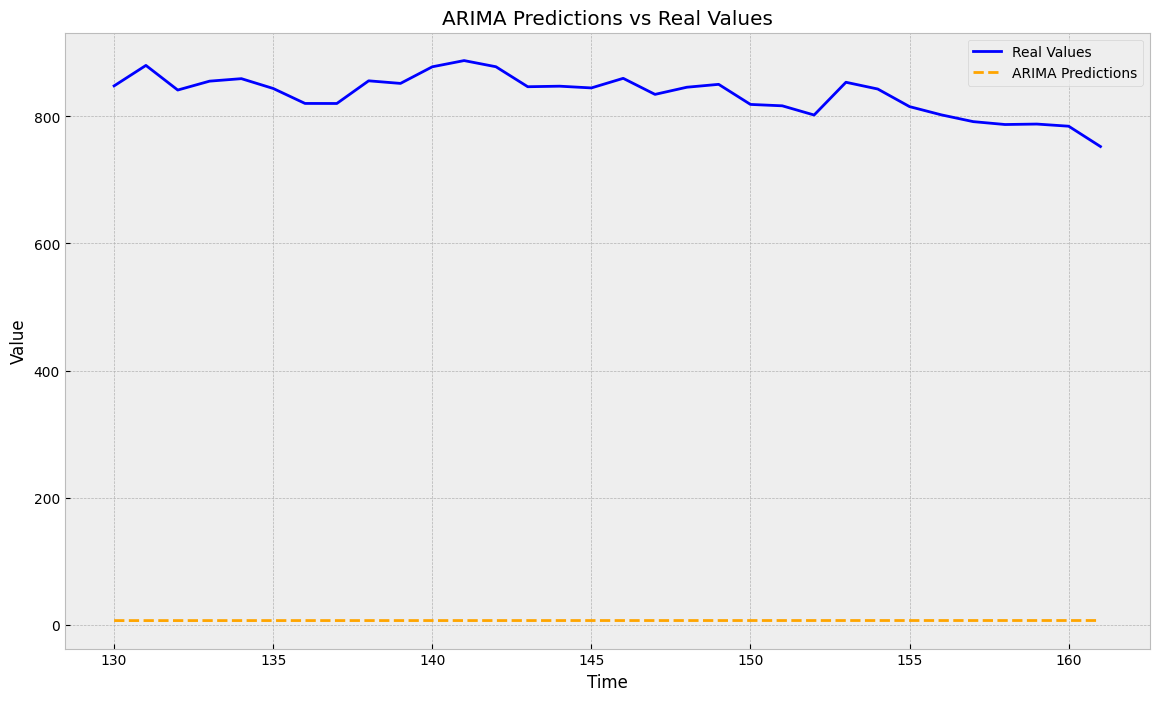

In [ ]:
# Визуализация ARIMA прогноза
plt.figure(figsize=(14, 8))
plt.plot(y_test.index, y_test.values, label='Real Values', color='blue')
plt.plot(y_test.index, arima_forecast, label='ARIMA Predictions', color='orange', linestyle='--')
plt.title('ARIMA Predictions vs Real Values')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:
# Сравнение всех моделей
results_df = pd.DataFrame({
    'Model': ['ARIMA', 'Random Forest', 'Linear Regression'],
    'RMSE': [arima_rmse, rf_rmse, lr_rmse],
    'MAE': [arima_mae, rf_mae, lr_mae]
})

print("\nComparison of Models:")
print(results_df)


Comparison of Models:
               Model        RMSE         MAE
0              ARIMA  828.506611  827.909394
1      Random Forest   32.145491   26.940462
2  Linear Regression   24.305831   18.691555


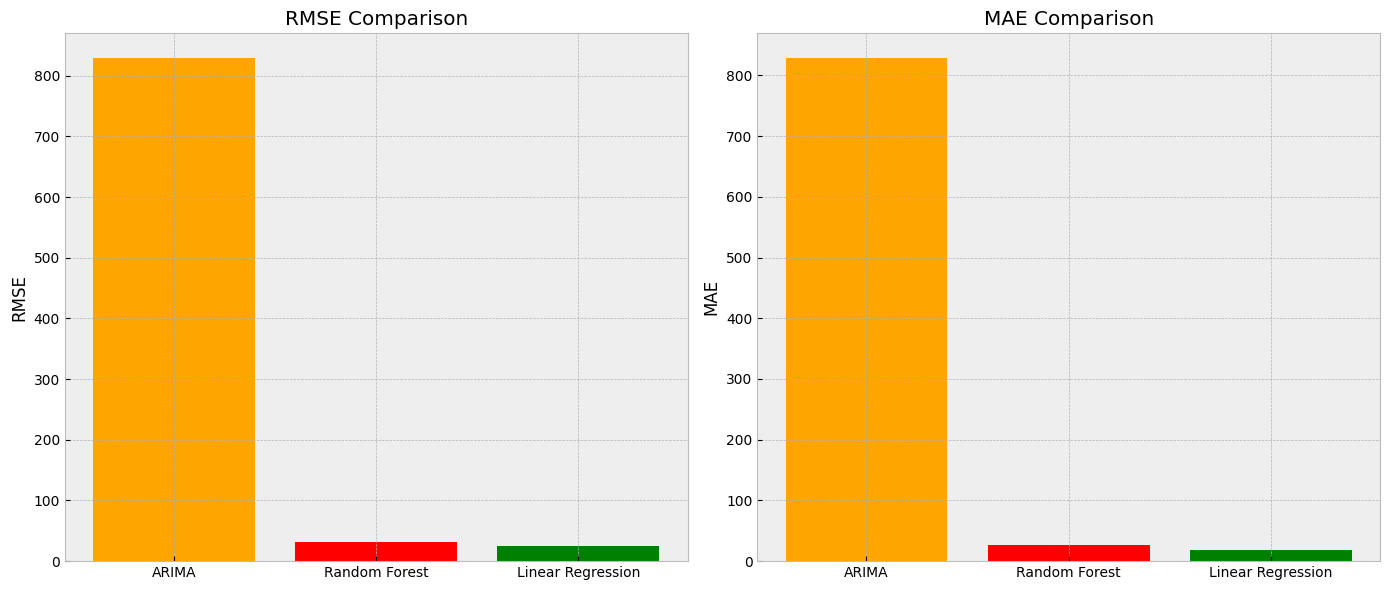

In [ ]:
# Визуализация сравнения
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].bar(results_df['Model'], results_df['RMSE'], color=['orange', 'red', 'green'])
ax[0].set_title('RMSE Comparison')
ax[0].set_ylabel('RMSE')

ax[1].bar(results_df['Model'], results_df['MAE'], color=['orange', 'red', 'green'])
ax[1].set_title('MAE Comparison')
ax[1].set_ylabel('MAE')

plt.tight_layout()
plt.show()

# Вывод:

Для этого временного ряда классические ML модели (Linear Regression, Random Forest) работают значительно лучше, чем ARIMA.

Linear Regression — самая простая, но и самая точная.

Это может говорить о том, что линейные зависимости в данных сильнее, чем сложные нелинейные, или что ARIMA не подходит для этого типа данных.